# Out-of-the-box evaluation on INPE test annotations

Evaluates the best DeepGlobe checkpoint (merged Agriculture+Rangeland, val mIoU 67.75 / 81.3 excl. Unknown) on the first hand-annotated CBERS-4A patches — **zero fine-tuning**. This is the transfer baseline every fine-tune run must beat.

**Data**: `data/cvat_patches/test_cvat/` — 1024×1024 SFIM-pansharpened patches (per-scene p2–p98 stretch + gamma 0.45, same transform as training patches will use). Masks are the CVAT "Segmentation mask 1.1" export (`SegmentationClass/`, VOC RGB colors, old 7-class taxonomy — merged to 6 at load time).

**Tiling**: 1024 → 16 non-overlapping 256px tiles per patch.

**Unknown threshold — why 5% and how it interacts with clouds**

In DeepGlobe, Unknown is rare and mostly image-border artifacts, so a 5% cutoff discards almost nothing. Here Unknown carries double duty: (a) genuinely unknowable ground (clouds + shadow, per annotation policy) and (b) anything left unannotated (CVAT background is also black). That makes it far more frequent, and a hard 5% cutoff would silently drop every cloudy tile — biasing the eval toward easy clear-sky tiles and shrinking an already tiny test set.

The fix used here: **Unknown pixels are excluded from scoring entirely** (they are not reliable labels either way), so a tile with 20% cloud still contributes its 80% labeled pixels. The threshold then only needs to remove tiles that are *mostly* unlabeled and would contribute noise-dominated statistics. With Unknown masked out of the metric, the threshold is kept at the requested 5% for comparability with the DeepGlobe pipeline, but the cell below also prints how many tiles survive at 25% and 50% — if 5% discards a large share, prefer 25%: same metric validity (Unknown never scored), more data.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import tensorflow as tf
from PIL import Image

DATA_DIR = Path('data/cvat_patches/test_cvat')
MASK_DIR = DATA_DIR / 'first_test_inpe_masks' / 'SegmentationClass'
MODEL_PATH = 'models/deepglobe_unet/best-20260702-downsample-overlap-color-aug-dropout-30-merged-class-batch-32-lr-1e-4-miou-67.keras'

TILE = 256
UNKNOWN_THRESH = 0.05   # discard tile if Unknown fraction >= this

N_CLASSES = 6
CLASS_NAMES = ['Urban', 'Agriculture_Rangeland', 'Forest', 'Water', 'Barren', 'Unknown']
UNKNOWN_IDX = 5

# display colors (merged class = yellow, as in results notebook)
CLASS_COLORS = np.array([
    [0, 255, 255],    # Urban
    [255, 255, 0],    # Agriculture_Rangeland
    [0, 255, 0],      # Forest
    [0, 0, 255],      # Water
    [255, 255, 255],  # Barren
    [0, 0, 0],        # Unknown
], dtype=np.uint8)

# CVAT export uses the old 7-class DeepGlobe colors -> merged 6-class index.
# background (0,0,0) == Unknown: unannotated pixels are treated as Unknown.
CVAT_COLOR_TO_CLASS = {
    (0, 255, 255):   0,  # Urban
    (255, 255, 0):   1,  # Agriculture
    (255, 0, 255):   1,  # Rangeland (merged)
    (0, 255, 0):     2,  # Forest
    (0, 0, 255):     3,  # Water
    (255, 255, 255): 4,  # Barren
    (0, 0, 0):       5,  # Unknown / background
}

def rgb_mask_to_labels(mask_rgb: np.ndarray) -> np.ndarray:
    """(H,W,3) uint8 -> (H,W) int32 class index."""
    labels = np.full(mask_rgb.shape[:2], UNKNOWN_IDX, dtype=np.int32)
    for color, idx in CVAT_COLOR_TO_CLASS.items():
        labels[np.all(mask_rgb == color, axis=-1)] = idx
    return labels

I0000 00:00:1783351427.165294   23098 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Load annotated pairs, tile to 256px, filter by Unknown fraction
mask_paths = sorted(MASK_DIR.glob('*.png'))
print(f'{len(mask_paths)} annotated patches')

all_imgs, all_lbls, all_tags, all_unk = [], [], [], []
for mp in mask_paths:
    img = np.array(Image.open(DATA_DIR / mp.name).convert('RGB'))
    lbl = rgb_mask_to_labels(np.array(Image.open(mp).convert('RGB')))
    assert img.shape[:2] == lbl.shape
    H, W = lbl.shape
    for r in range(0, H - TILE + 1, TILE):
        for c in range(0, W - TILE + 1, TILE):
            t_lbl = lbl[r:r + TILE, c:c + TILE]
            all_imgs.append(img[r:r + TILE, c:c + TILE])
            all_lbls.append(t_lbl)
            all_tags.append(f'{mp.stem}_t{r:04d}_{c:04d}')
            all_unk.append((t_lbl == UNKNOWN_IDX).mean())

all_unk = np.array(all_unk)
for th in (UNKNOWN_THRESH, 0.25, 0.50):
    print(f'  threshold {th:>4.0%}: keep {(all_unk < th).sum():3d} / {len(all_unk)} tiles')

keep = all_unk < UNKNOWN_THRESH
images = np.stack([im for im, k in zip(all_imgs, keep) if k])
labels = np.stack([lb for lb, k in zip(all_lbls, keep) if k])
tags   = [t for t, k in zip(all_tags, keep) if k]
print(f'\nUsing threshold {UNKNOWN_THRESH:.0%}: {len(images)} tiles '
      f'({(~keep).sum()} discarded, mean Unknown in discarded '
      f'{all_unk[~keep].mean():.1%})' if (~keep).any() else f'\n{len(images)} tiles, none discarded')

# GT class distribution over kept tiles
counts = np.bincount(labels.ravel(), minlength=N_CLASSES)
for n, ct in zip(CLASS_NAMES, counts):
    print(f'  {n:<22} {ct / counts.sum():6.2%}')

25 annotated patches
  threshold   5%: keep 256 / 400 tiles
  threshold  25%: keep 314 / 400 tiles
  threshold  50%: keep 338 / 400 tiles

Using threshold 5%: 256 tiles (144 discarded, mean Unknown in discarded 42.4%)
  Urban                   0.00%
  Agriculture_Rangeland   5.62%
  Forest                 93.02%
  Water                   0.39%
  Barren                  0.71%
  Unknown                 0.27%


In [3]:
# Load model and predict (raw uint8 in: EfficientNetB0 rescales internally)
# batch_size=8: 4GB GPU OOMs at 16
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
assert model.output_shape[-1] == N_CLASSES, model.output_shape

probs = model.predict(images.astype(np.float32), batch_size=8, verbose=1)
preds = np.argmax(probs, axis=-1).astype(np.int32)
print('predictions:', preds.shape)

I0000 00:00:1783351435.608812   23098 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2140 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1783351439.987198   23183 service.cc:153] XLA service 0x7ce3400adf10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783351439.987217   23183 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1783351440.079572   23183 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783351440.857709   23183 cuda_dnn.cc:461] Loaded cuDNN version 92200
W0000 00:00:1783351446.388205   23254 hlo_rematerialization.cc:3204] Can't reduce memory use below 2.72GiB (2923957330 bytes) by rematerialization; only 

 2/32 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step  

I0000 00:00:1783351498.312795   23183 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 61s 47ms/step
predictions: (256, 256, 256)


In [4]:
# Metrics. Unknown GT pixels excluded from scoring (unreliable labels:
# clouds + unannotated background). Prediction of Unknown on labeled
# pixels still counts as an error against the GT class.
valid = labels != UNKNOWN_IDX
y_true = labels[valid]
y_pred = preds[valid]
print(f'{valid.mean():.1%} of pixels scored '
      f'({(~valid).sum():,} Unknown px excluded)')

cm = np.zeros((N_CLASSES, N_CLASSES), dtype=np.int64)
np.add.at(cm, (y_true, y_pred), 1)

px_acc = np.trace(cm) / cm.sum()

inter = np.diag(cm).astype(np.float64)
union = cm.sum(0) + cm.sum(1) - np.diag(cm)
present = cm.sum(1) > 0                      # classes with GT pixels
iou = np.where(union > 0, inter / np.maximum(union, 1), np.nan)

print(f'\nPixel accuracy: {px_acc:.4f}')
print(f'{"class":<22} {"IoU":>8} {"GT px":>12} {"pred px":>12}')
for i, n in enumerate(CLASS_NAMES):
    iou_s = f'{iou[i]:.4f}' if present[i] else '   n/a'
    print(f'{n:<22} {iou_s:>8} {cm.sum(1)[i]:>12,} {cm.sum(0)[i]:>12,}')

miou_present = np.nanmean(np.where(present, iou, np.nan))
print(f'\nmIoU over classes present in GT: {miou_present:.4f}')
print(f'(DeepGlobe val reference, 5-class excl. Unknown: 0.813)')
print(f'pred = Unknown on labeled px: {cm.sum(0)[UNKNOWN_IDX] / cm.sum():.2%}')

99.7% of pixels scored (44,518 Unknown px excluded)

Pixel accuracy: 0.2328
class                       IoU        GT px      pred px
Urban                       n/a            0    3,905,102
Agriculture_Rangeland    0.0703      942,326    7,345,483
Forest                   0.2057   15,606,165    3,710,936
Water                    0.2026       65,541       99,832
Barren                   0.0159      118,666    1,671,345
Unknown                     n/a            0            0

mIoU over classes present in GT: 0.1236
(DeepGlobe val reference, 5-class excl. Unknown: 0.813)
pred = Unknown on labeled px: 0.00%


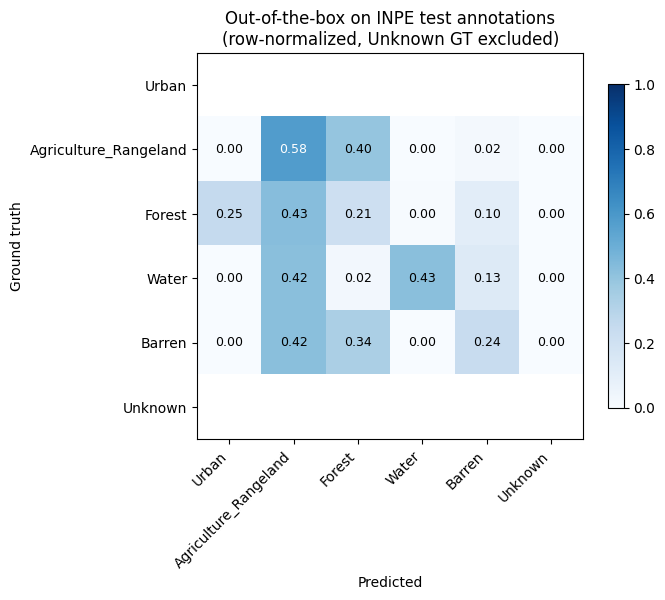

In [5]:
# Row-normalized confusion matrix (recall per GT class)
row_sum = cm.sum(1, keepdims=True)
cm_recall = np.where(row_sum > 0, cm / np.maximum(row_sum, 1), np.nan)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_recall, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(N_CLASSES), CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(N_CLASSES), CLASS_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('Ground truth')
ax.set_title('Out-of-the-box on INPE test annotations\n(row-normalized, Unknown GT excluded)')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if not np.isnan(cm_recall[i, j]):
            ax.text(j, i, f'{cm_recall[i, j]:.2f}', ha='center', va='center',
                    color='white' if cm_recall[i, j] > 0.5 else 'black', fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

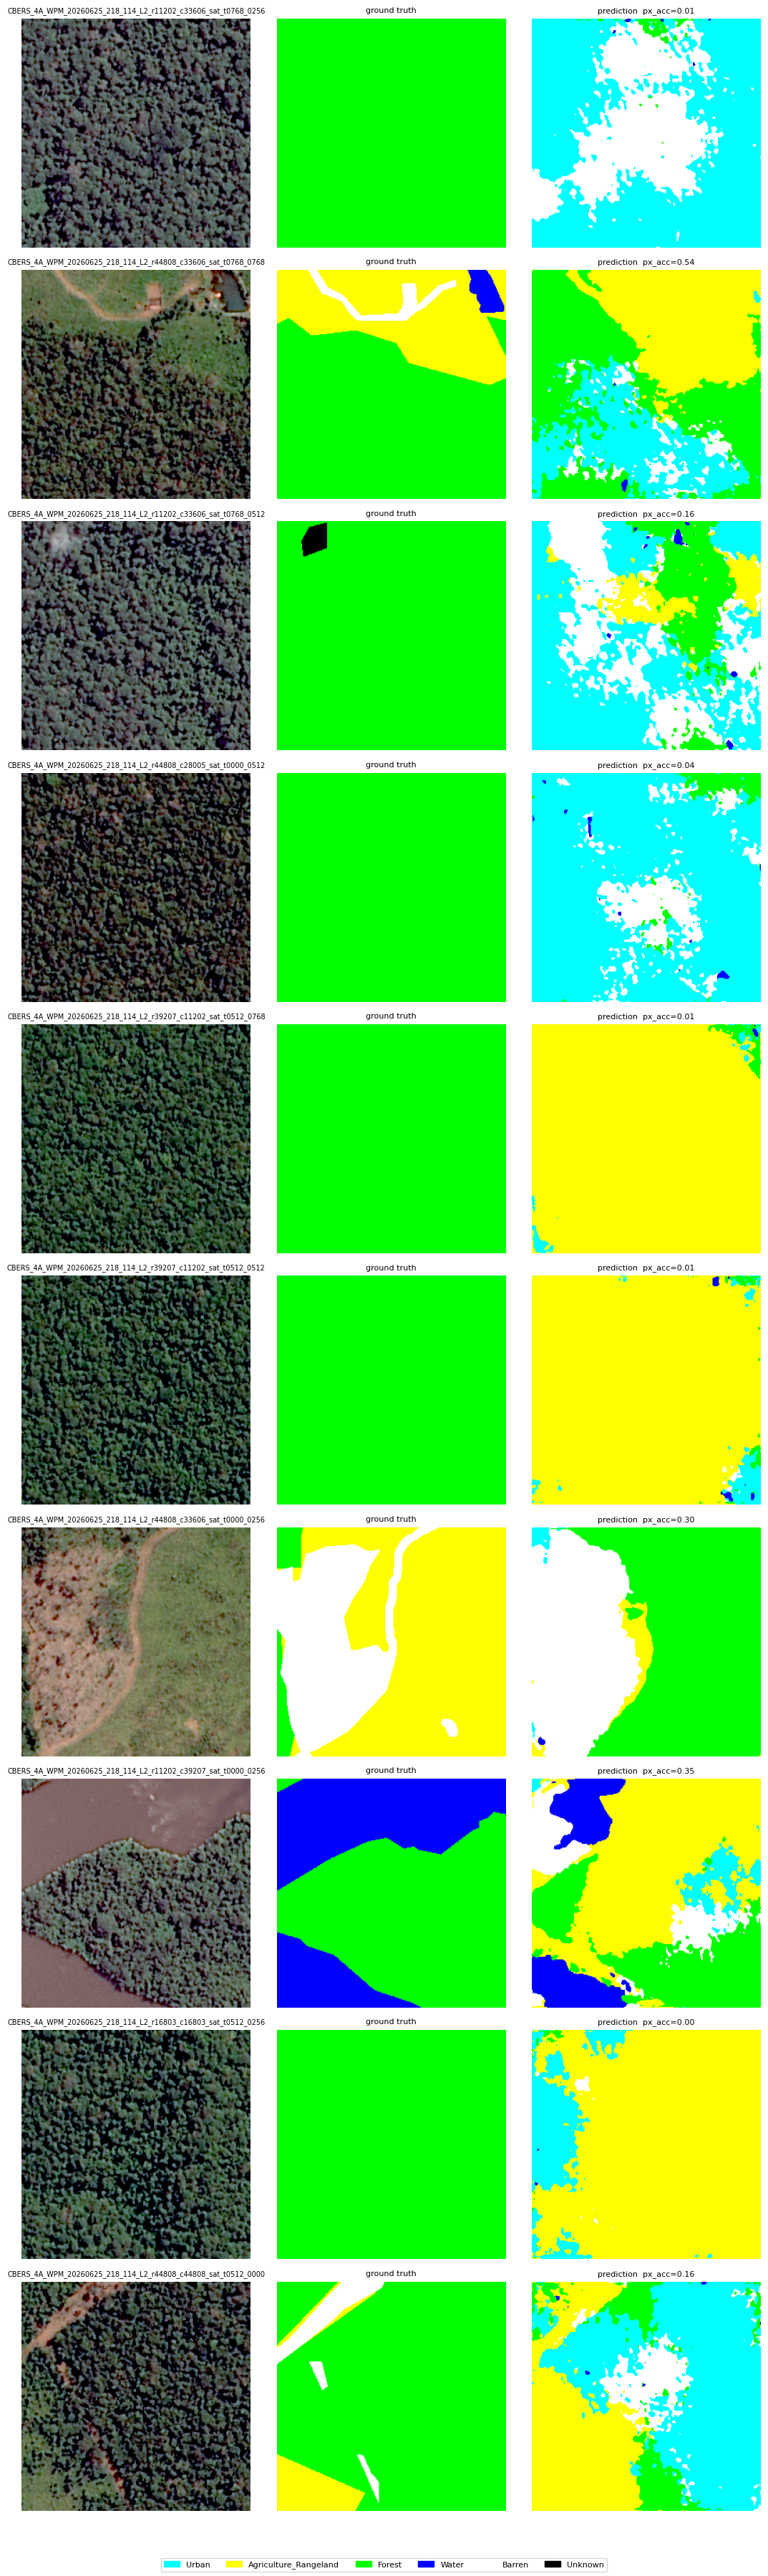

In [6]:
# Visualize 10 random evaluated tiles: image / GT / prediction
N_SHOW = 10
rng = np.random.default_rng(42)
sel = rng.choice(len(images), size=min(N_SHOW, len(images)), replace=False)

legend_patches = [mpatches.Patch(color=CLASS_COLORS[i] / 255, label=CLASS_NAMES[i])
                  for i in range(N_CLASSES)]

fig, axes = plt.subplots(len(sel), 3, figsize=(11, 3.6 * len(sel)))
for ax_row, idx in zip(axes, sel):
    v = labels[idx] != UNKNOWN_IDX
    acc = (preds[idx][v] == labels[idx][v]).mean() if v.any() else np.nan
    ax_row[0].imshow(images[idx])
    ax_row[0].set_title(tags[idx], fontsize=7)
    ax_row[1].imshow(CLASS_COLORS[labels[idx]])
    ax_row[1].set_title('ground truth', fontsize=8)
    ax_row[2].imshow(CLASS_COLORS[preds[idx]])
    ax_row[2].set_title(f'prediction  px_acc={acc:.2f}', fontsize=8)
    for ax in ax_row:
        ax.axis('off')
fig.legend(handles=legend_patches, loc='lower center', ncol=6, fontsize=8)
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()